In [19]:
# Imports
import utils_plotting
import pickle
import jax.numpy as jnp
from utils_inverse import _tree_to_jnp
import matplotlib.pyplot as plt
from utils_FaIR_JAX import generate_calib_data
import utils_FaIR_JAX
import numpy as np
import utils_inverse
import jax

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Figure X: Optimization pipeline overview

In [124]:
path_inverse = f'checkpoints/co2/inverse_gaussian_tier1_co2_only.pkl'
with open(path_inverse, "rb") as f:
  raw = pickle.load(f)
res = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }

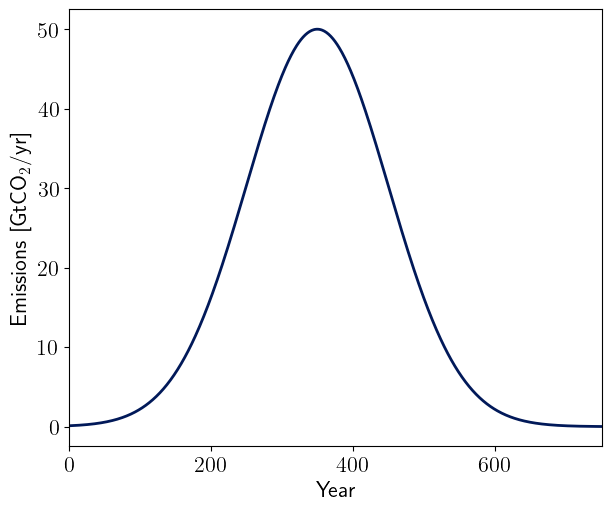

In [144]:
utils_plotting.plot_init(res, save=True)

In [149]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)
group = ['historical','H-ext','M','ML','L','VLHO','VLLO-ext']
years = [np.arange(1750, 2024), np.arange(2024, 2501), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2501)]

tier1 = []
for i, scen in enumerate(group):
  tier1.append(emis_dict_calib_JAX[scen][0])

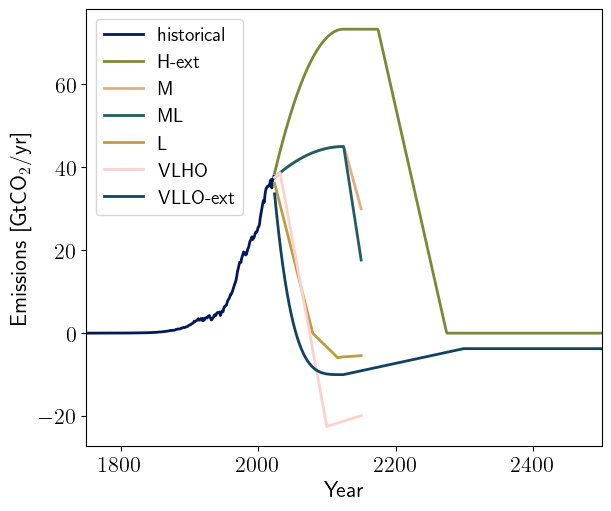

In [154]:
utils_plotting.plot_tier1(years, tier1, group, save=True)

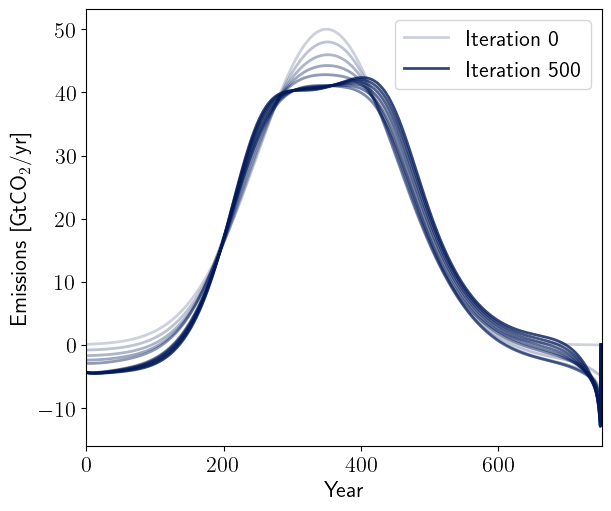

In [157]:
utils_plotting.plot_updates(res, save=True)

### Figure X: RMSE comparison across single-forcing experiments

In [38]:
agents = ['co2','ch4','n2o','Sulfur','BC']
results_inverse, results_baseline = [], []
for a in agents:
  path_inverse = f'checkpoints/{a}/inverse_constant_tier1_{a}_only_old.pkl'
  path_baseline = f'checkpoints/{a}/baseline_{a}_only_old.pkl'
  with open(path_inverse, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  with open(path_baseline, "rb") as f:
    res_base = pickle.load(f)
  results_inverse.append(out)
  results_baseline.append(res_base['Tier 1']['mean'])

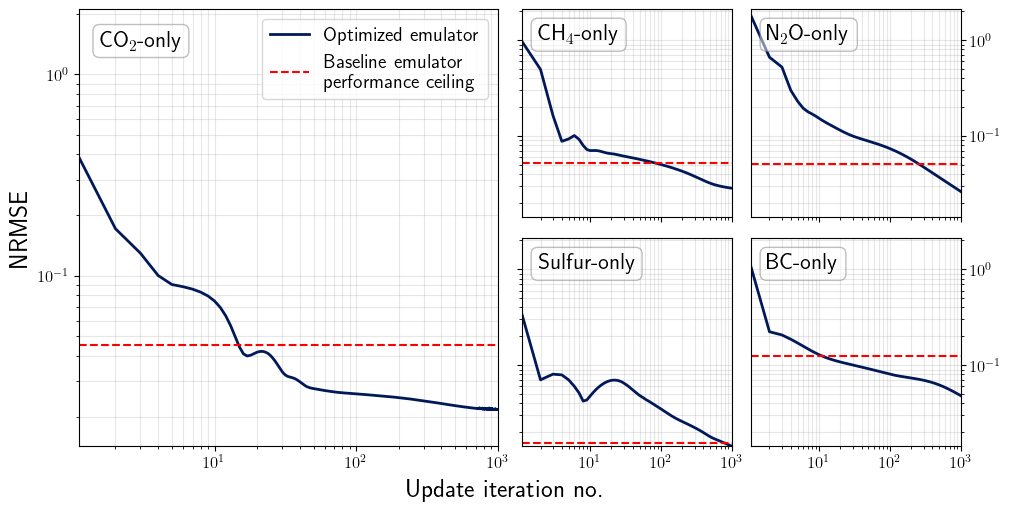

In [39]:
utils_plotting.plot_rmse_comparison_single(results_inverse, results_baseline, ['CO$_2$','CH$_4$','N$_2$O','Sulfur','BC'], save=True)

### Figure X: Optimal emissions profile across different optimization targets

In [46]:
from utils_FaIR_JAX import generate_calib_data

agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

plot_paths = ['checkpoints/co2/inverse_H-ext_constant_co2_only_old.pkl',
              #'checkpoints/co2/inverse_VLLO-ext_constant_co2_only.pkl',
              'checkpoints/co2/inverse_constant_DECK_co2_only_old.pkl',
              'checkpoints/co2/inverse_constant_tier1_co2_only_old.pkl']

opt_emissions = []
for i, path in enumerate(plot_paths):
  with open(path, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  opt_emissions.append([])
  for series in out['U_traj']:
    opt_emissions[i].append(series['CO2'])

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/co2/inverse_H-ext_constant_co2_only_old.pkl'

In [5]:
groups = [['H-ext'],['1pctCO2','abrupt-4xCO2'],['historical','H-ext','M','ML','L','VLHO','VLLO-ext']]

target_emissions = []
for i, g in enumerate(groups):
  target_emissions.append([])
  for scen in g:
    target_emissions[i].append(emis_dict_calib_JAX[scen][0])
import numpy as np
years = [[np.arange(2024, 2501)],
         [np.arange(1750, 1901), np.arange(1750, 2051)],
         [np.arange(1750, 2024), np.arange(2024, 2501), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2501)]]

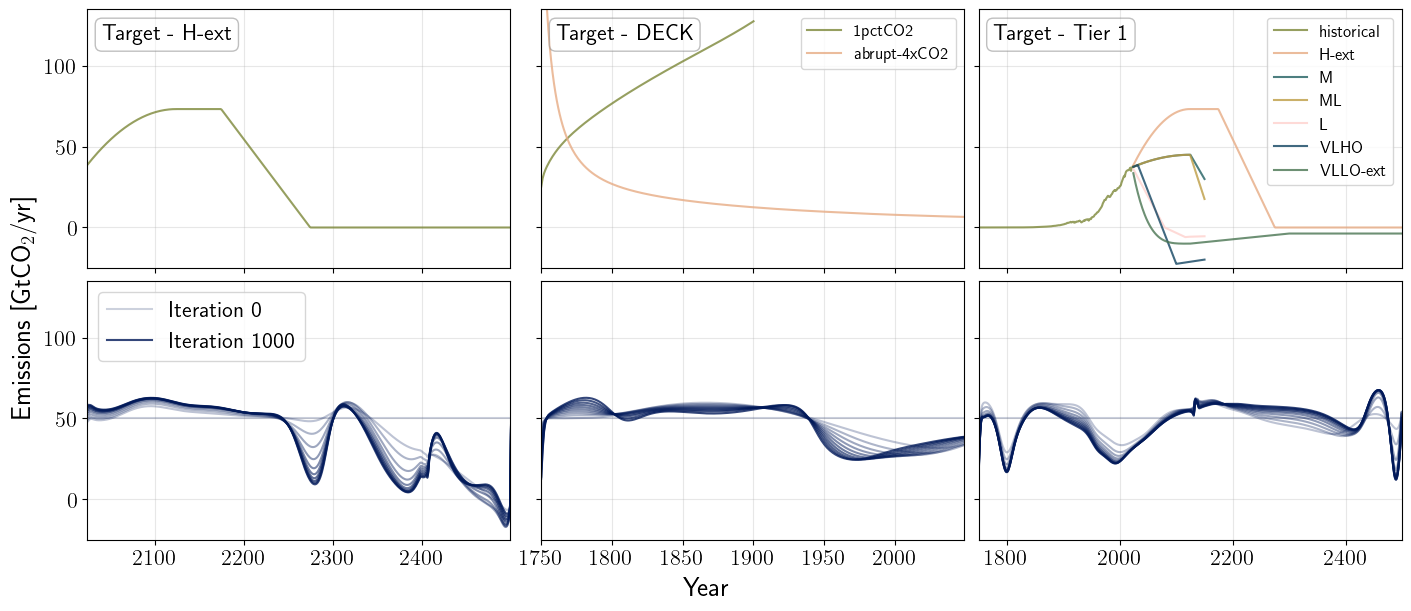

In [15]:
targets = ['H-ext','DECK','Tier 1']
utils_plotting.plot_emissions_grid(opt_emissions, target_emissions, years, targets, groups, save=False)

In [40]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

path = 'checkpoints/co2/inverse_H-ext_constant_co2_only_old.pkl'
with open(path, "rb") as f:
  raw = pickle.load(f)
opt_results = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }

opt_emissions = []
for series in opt_results['U_traj']:
  opt_emissions.append(series['CO2'])

target_emissions = [emis_dict_calib_JAX['H-ext'][0].copy()]
years = np.arange(2024, 2501)

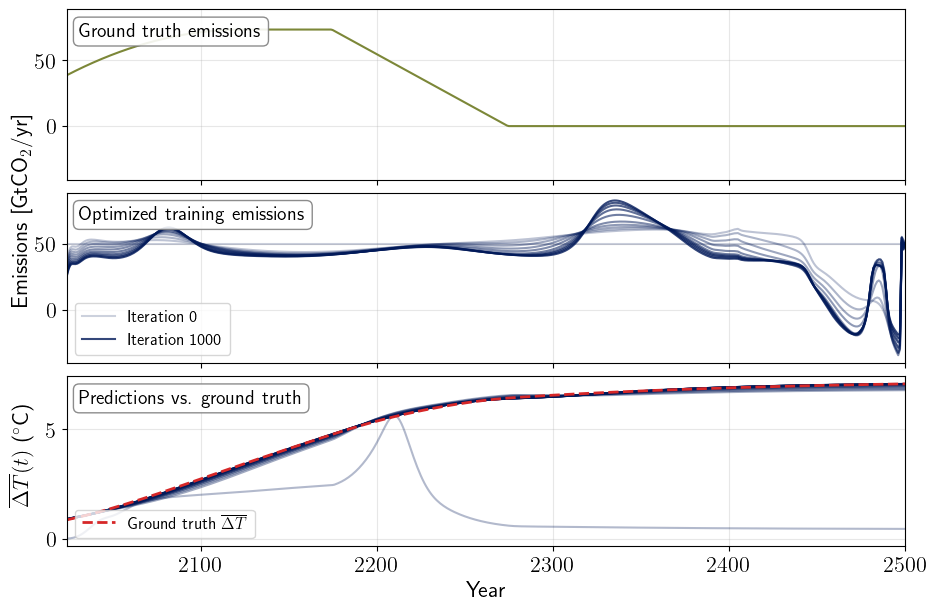

In [41]:
save_path = 'Figures/co2_H-ext_example'
utils_plotting.plot_stacked_results(target_emissions, years, opt_emissions, opt_results, save_path=None)

### Figure X: NRMSE comparison, multi-forcing w/ emissions data

In [35]:
agents = ['co2','ch4','n2o','Sulfur','BC']
path_inverse = f'checkpoints/multi/inverse_constant_tier1_all_ghgs_old.pkl'
path_baseline = f'checkpoints/multi/baseline_all_ghgs.pkl'
with open(path_inverse, "rb") as f:
  raw = pickle.load(f)
out = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }
with open(path_baseline, "rb") as f:
  res_base = pickle.load(f)

results_inverse = out
results_baseline = res_base['Tier 1']['mean']

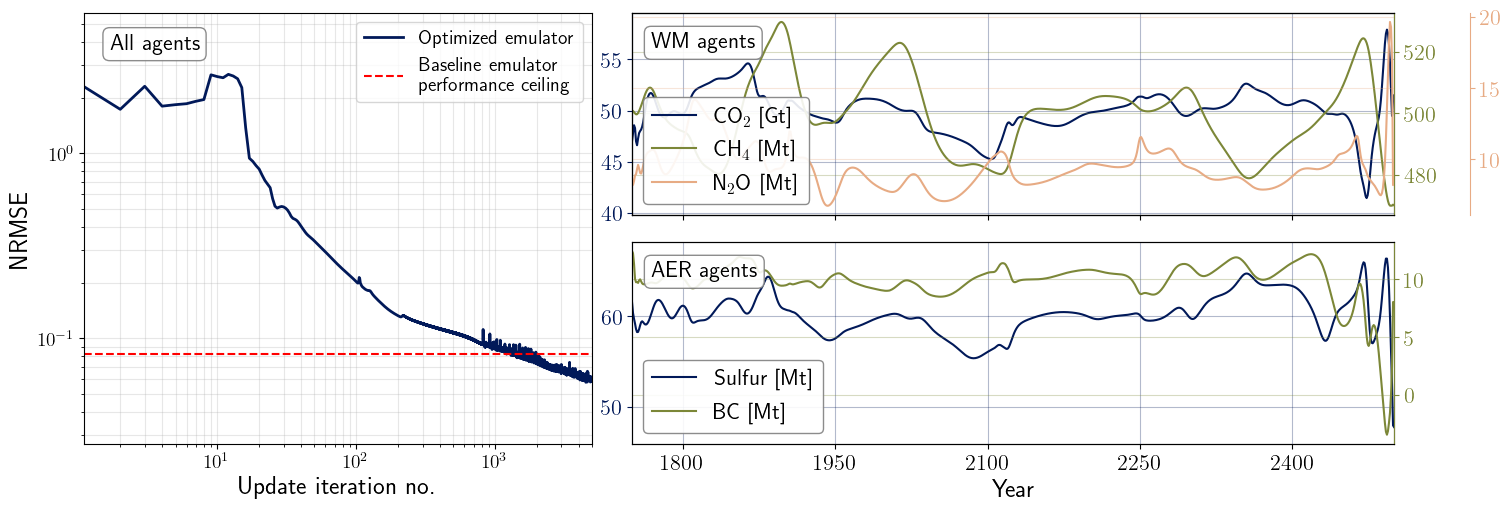

In [36]:
utils_plotting.plot_rmse_comparison_multi(results_inverse, results_baseline, save=False)

### Figure X: Performance over several experiments for multi-forcing optimization

In [9]:
plot_paths = ['checkpoints/multi/inverse_constant_tier1_all_ghgs.pkl',
              'checkpoints/multi/inverse_constant_DAMIP_all_ghgs.pkl',
              'checkpoints/multi/inverse_constant_GeoMIP_all_ghgs.pkl',
              'checkpoints/multi/inverse_constant_all_all_ghgs.pkl']

opt_CO2, opt_Sulfur = [], []
for i, path in enumerate(plot_paths):
  with open(path, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  opt_CO2.append(out['U_traj'][-1]['CO2'])
  opt_Sulfur.append(out['U_traj'][-1]['Sulfur'])

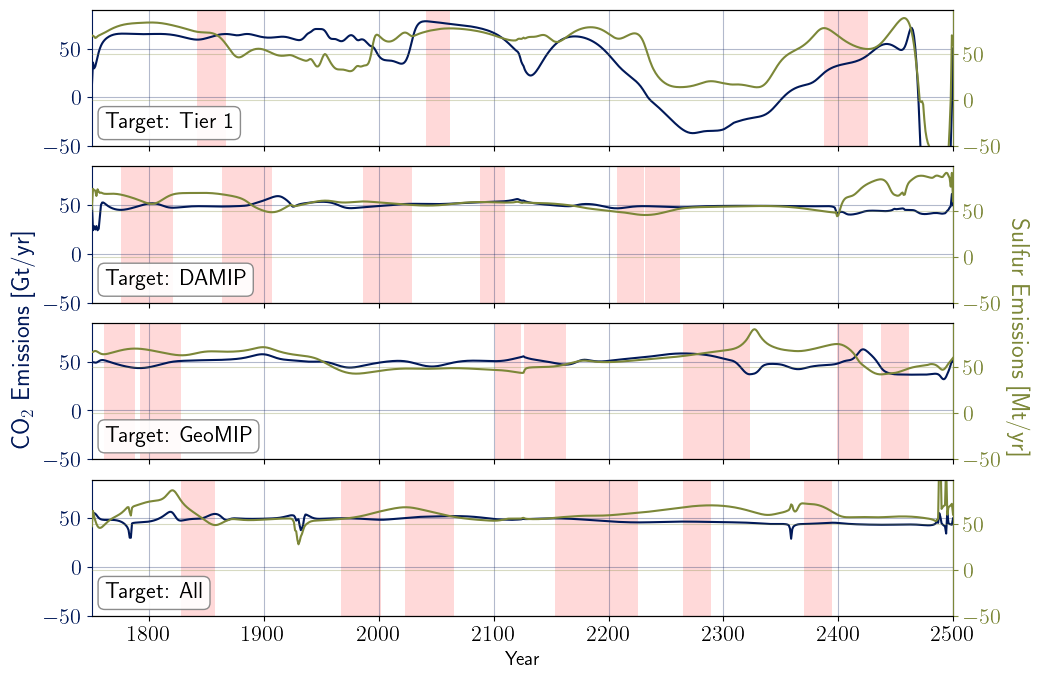

In [10]:
utils_plotting.plot_co2_sulfur(opt_CO2, opt_Sulfur, save=True)

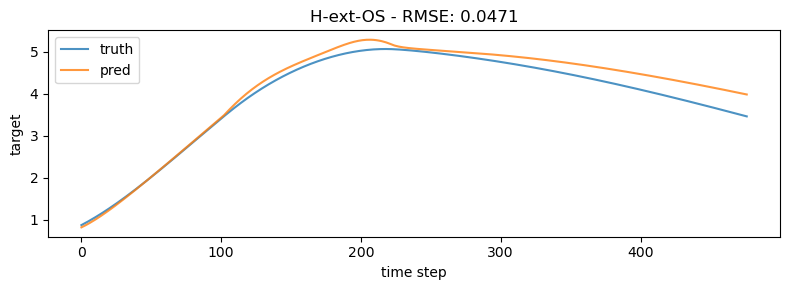


Tier 1 mean scaled RMSE: 0.0209
  historical                      0.0195
  H-ext                           0.0355
  M                               0.0056
  ML                              0.0057
  L                               0.0123
  VLLO-ext                        0.0539
  VLHO                            0.0137

Tier 2 mean scaled RMSE: 0.0553
  H-ext-OS                        0.0477
  M-ext                           0.0152
  ML-ext                          0.0864
  L-ext                           0.0779
  VLHO-ext                        0.0848

DECK mean scaled RMSE: 0.0396
  abrupt-4xCO2                    0.0592
  1pctCO2                         0.0200

CS3 mean scaled RMSE: 0.0174
  AA                              0.0199
  CT                              0.0059

All mean scaled RMSE: 0.0420
  historical                      0.0265
  H-ext                           0.0373
  M                               0.0081
  ML                              0.0082
  L                    

NameError: name 'pickle' is not defined

In [1]:
import utils_FaIR_JAX, utils_inverse
import jax

agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "All": emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX
}

emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

training_paths = ['checkpoints/co2/inverse_constant_tier1_co2_only_old.pkl',
                  'checkpoints/co2/inverse_constant_tier2_co2_only_old.pkl',
                  'checkpoints/co2/inverse_constant_DECK_co2_only_old.pkl',
                  'checkpoints/co2/inverse_constant_CS3_co2_only_old.pkl',
                  'checkpoints/co2/inverse_constant_all_co2_only_old.pkl']
optimal_results = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    test_sets=test_sets,
    params0=params0,
    active_agents=('CO2'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

for test_set in optimal_results[training_paths[0]]['metrics']:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in optimal_results[training_paths[0]]['metrics'][test_set]:
        optimal_results[training_paths[0]]['metrics'][test_set].pop('historical')
    per_scen = optimal_results[training_paths[0]]['metrics'][test_set]
    mean_err = optimal_results[training_paths[0]]['metrics'][test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")

In [10]:
path = 'checkpoints/co2/baseline_co2_only_old.pkl'
with open(path, 'rb') as file:
    baseline_results = pickle.load(file)

train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt CS3', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3']
weights = [7, 5, 2, 2]
vmax = 0.1
#utils_plotting.plot_single_heatmap(baseline_results, optimal_results, train_scenarios, test_scenarios, training_paths, weights, vmax, save=False)

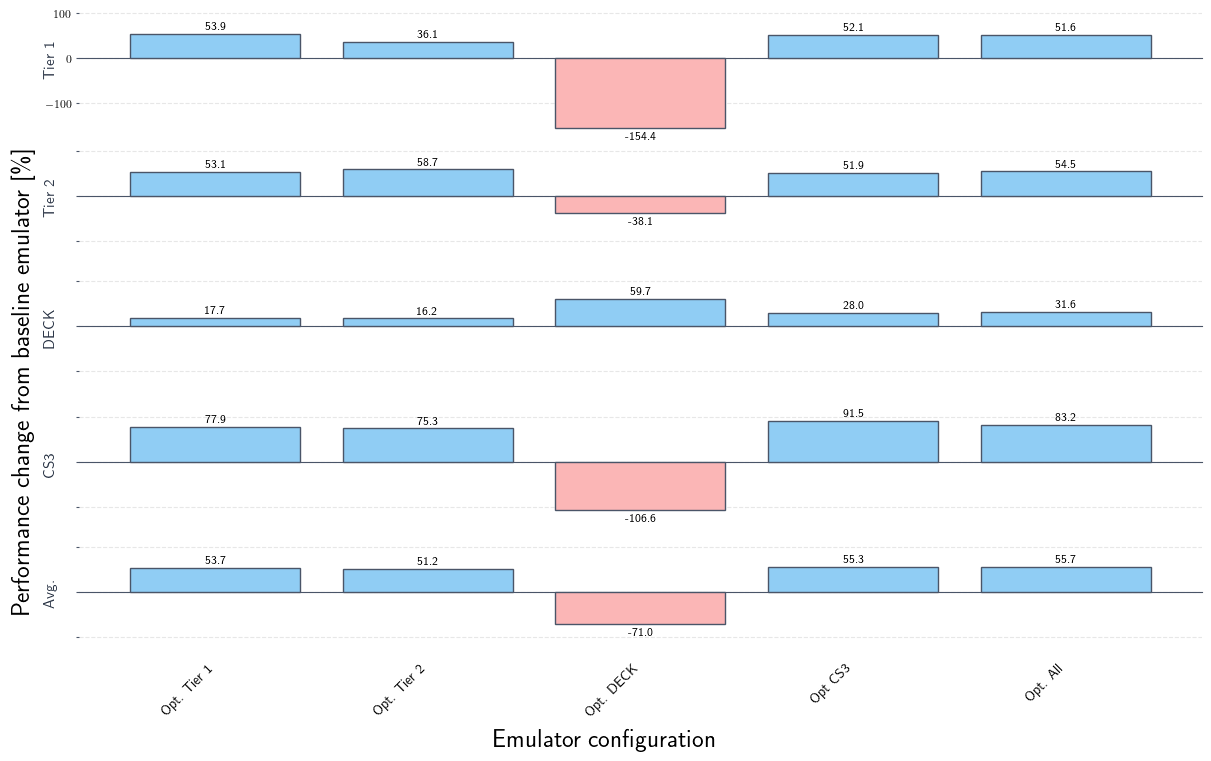

In [43]:
utils_plotting.plot_faceted_improvement_bars(baseline_results, optimal_results,
                                  train_scenarios,
                                  test_scenarios,
                                  training_paths,
                                  weights,
                                  long_title=None,
                                  save=False,
                                  figname=None)

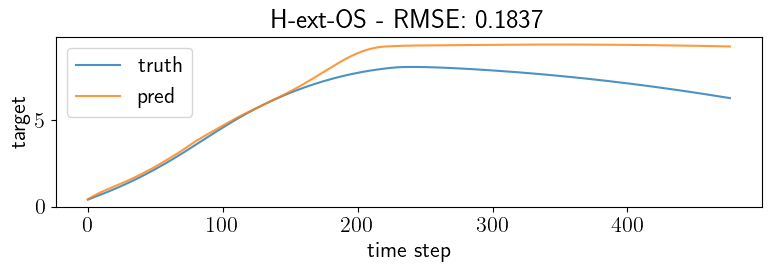

||grad BC||: 0.0037961045745760202
||grad CH4||: 5.949837213847786e-05
||grad CO2||: 0.00024814915377646685
||grad N2O||: 0.0014457900542765856
||grad Sulfur||: 8.262554911198094e-05

Tier 1 mean scaled RMSE: 0.0826
  historical                      0.2742
  H-ext                           0.0095
  M                               0.0317
  ML                              0.0342
  L                               0.0744
  VLLO-ext                        0.0826
  VLHO                            0.0714

Tier 2 mean scaled RMSE: 0.1943
  historical                      0.2742
  H-ext-OS                        0.1837
  M-ext                           0.2378
  ML-ext                          0.1828
  L-ext                           0.1839
  VLHO-ext                        0.1032

DECK mean scaled RMSE: 1.0005
  abrupt-4xCO2                    0.5934
  abrupt-4xCH4                    2.8575
  abrupt-4xN2O                    0.5503
  abrupt-4xSulfur                 0.3014
  abrupt-4xBC          

In [20]:
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

test_scen = 'historical'
utils_inverse.test_get_grad(test_scen, params0, emis_dict_train_JAX, train_data, test_data, active=("CO2","CH4", "N2O", "Sulfur", "BC"))

emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX, emis_dict_DAMIP_JAX, emis_dict_GeoMIP_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True, DAMIP=True, GeoMIP=True)
emis_dict_all_JAX = emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX | emis_dict_DAMIP_JAX | emis_dict_GeoMIP_JAX
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "DAMIP": emis_dict_DAMIP_JAX,
    "GeoMIP": emis_dict_GeoMIP_JAX,
    "All": emis_dict_all_JAX
}

paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden_sizes=[16],
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

for test_set in baseline_results:
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")

In [32]:
training_paths = ['checkpoints/multi/inverse_constant_tier1_all_ghgs_old.pkl',
                  'checkpoints/multi/inverse_constant_tier2_all_ghgs_old.pkl',
                  'checkpoints/multi/inverse_constant_DECK_all_ghgs_old.pkl',
                  'checkpoints/multi/inverse_constant_CS3_all_ghgs_old.pkl',
                  'checkpoints/multi/inverse_constant_DAMIP_all_ghgs_old.pkl',
                  'checkpoints/multi/inverse_constant_GeoMIP_all_ghgs_old.pkl',
                  'checkpoints/multi/inverse_constant_all_all_ghgs_old.pkl']
optimal_results = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    test_sets=test_sets,
    params0=params0,
    active_agents=('CO2','CH4','N2O','Sulfur','BC'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

In [33]:
for test_set in optimal_results[training_paths[0]]['metrics']:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in optimal_results[training_paths[0]]['metrics'][test_set]:
        optimal_results[training_paths[0]]['metrics'][test_set].pop('historical')
    per_scen = optimal_results[training_paths[0]]['metrics'][test_set]
    mean_err = optimal_results[training_paths[0]]['metrics'][test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0526
  historical                      0.0850
  H-ext                           0.0184
  M                               0.0151
  ML                              0.0198
  L                               0.0772
  VLLO-ext                        0.0874
  VLHO                            0.0651

Tier 2 mean scaled RMSE: 0.2956
  H-ext-OS                        0.1483
  M-ext                           0.5001
  ML-ext                          0.3848
  L-ext                           0.2776
  VLHO-ext                        0.3782

DECK mean scaled RMSE: 1.4430
  abrupt-4xCO2                    0.8145
  abrupt-4xCH4                    2.6565
  abrupt-4xN2O                    2.1250
  abrupt-4xSulfur                 0.1704
  abrupt-4xBC                     0.2987
  1pctCO2                         0.2093
  1pctCH4                         2.8045
  1pctN2O                         2.6283
  1pctSulfur                      0.6587
  1pctBC                          2.0638



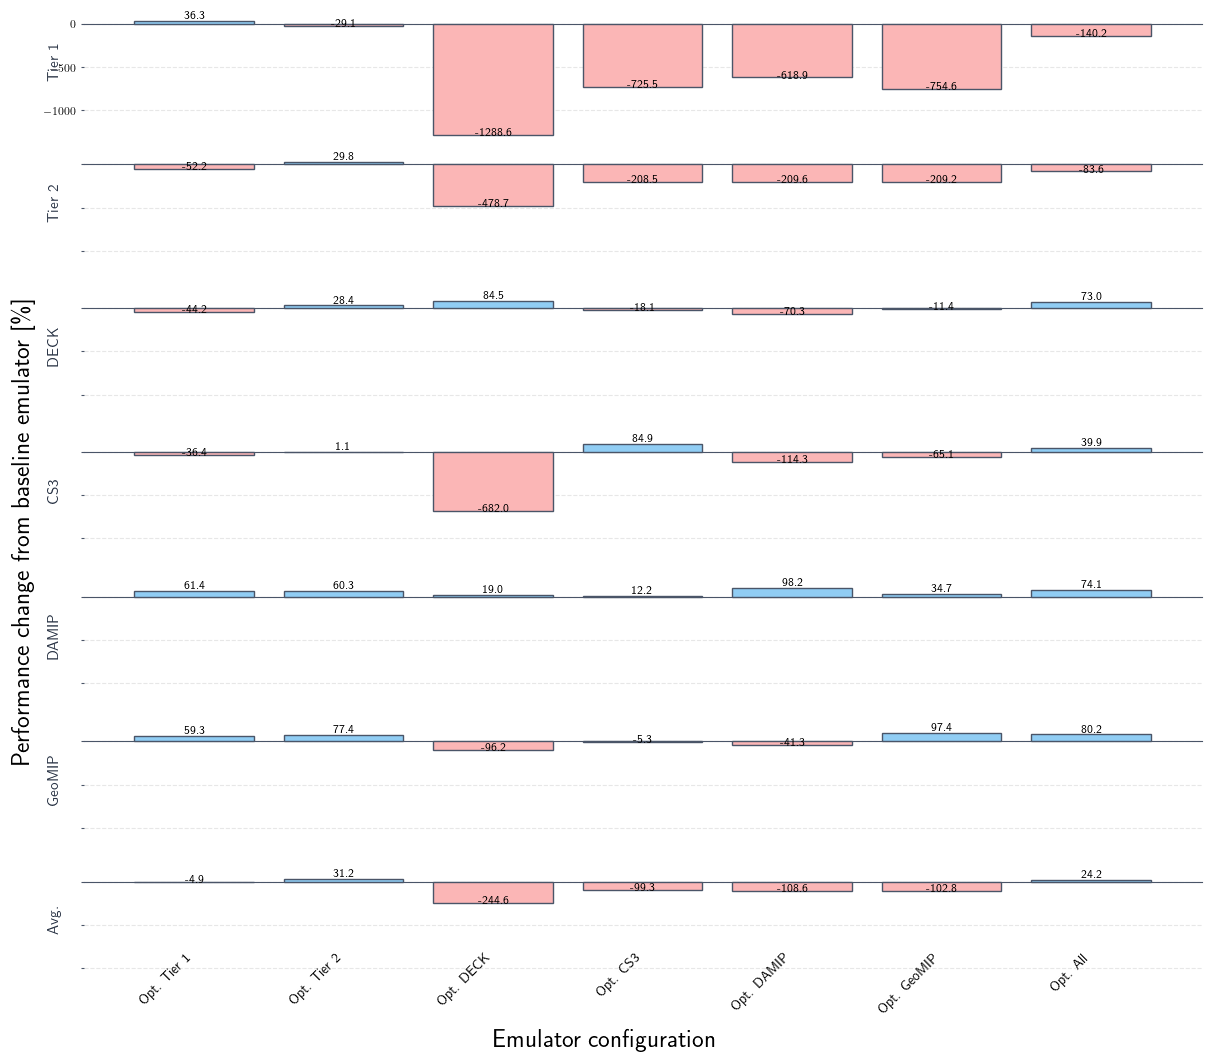

In [34]:
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. CS3', 'Opt. DAMIP', 'Opt. GeoMIP', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3', 'DAMIP', 'GeoMIP']
weights = [7, 5, 2, 2, 2, 1]
vmax = 1

utils_plotting.plot_faceted_improvement_bars(baseline_results, optimal_results,
                                  train_scenarios,
                                  test_scenarios,
                                  training_paths,
                                  weights,
                                  long_title=None,
                                  save=False,
                                  figname=None)